# 🔍 Notebook 2 — Anomaly Detection

We follow the full framework:

```
         RAW DATA
             │
     Data Quality Check
             │
  Distribution Tail Analysis
             │
      Isolation Forest
             │
   Regression Diagnostics
         ┌───┴───┐
      Leverage  Residual
         └───┬───┘
       Influence Check
             │
      Business Review
         ┌───┴───┐
      Genuine   Error
         │         │
       KEEP    FIX/REMOVE
```

**Input:** `outputs/df_profiled.parquet` · `outputs/meta.json`

**Output:** `outputs/df_clean.parquet` · `outputs/anomaly_report.csv`

---

## 2.1 — Load Data

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, warnings
warnings.filterwarnings('ignore')

df   = pd.read_parquet('../outputs/df_profiled.parquet')
meta = json.load(open('../outputs/meta.json'))

CLAIM_COUNT_COL  = meta['claim_count_col']
CLAIM_AMOUNT_COL = meta['claim_amount_col']
EXPOSURE_COL     = meta['exposure_col']
NUM_COLS         = meta['num_cols']
CAT_COLS         = meta['cat_cols']

print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')

Dataset: 111,617 rows × 11 cols


## 2.2 — Data Quality Check
Look for impossible values: negative ages, negative claim amounts, impossible vehicle ages etc.

In [33]:
def tool_check_data_quality(df, num_cols, claim_count_col=None, claim_amount_col=None):
    """
    Performs logical sanity checks on raw claims and rating data.
    
    What this tool does:
        Scans for physical and accounting impossibilities: negative values in rating
        variables, negative claim counts/amounts, and unlinked payouts (ClaimAmount > 0 with ClaimNb == 0).
        
    Why it is used (ASOP 23):
        Corrupt records distort regression slopes and must be trapped early before modeling.
        
    Returns:
        dict: Summary of detected anomalies and record counts.
    """
    issues = {}
    for col in num_cols:
        if col in df.columns:
            neg = (df[col] < 0).sum()
            if neg > 0:
                issues[f'{col}_negative'] = int(neg)
                
    if claim_amount_col and claim_amount_col in df.columns:
        neg_amt = (df[claim_amount_col] < 0).sum()
        if neg_amt > 0:
            issues['negative_claim_amounts'] = int(neg_amt)
            
    if claim_count_col and claim_count_col in df.columns:
        neg_cnt = (df[claim_count_col] < 0).sum()
        if neg_cnt > 0:
            issues['negative_claim_counts'] = int(neg_cnt)
            
    if claim_count_col and claim_amount_col and claim_count_col in df.columns and claim_amount_col in df.columns:
        zero_claims_pos_amt = ((df[claim_count_col] == 0) & (df[claim_amount_col] > 0)).sum()
        if zero_claims_pos_amt > 0:
            issues['zero_claims_positive_amount'] = int(zero_claims_pos_amt)
            
    return issues

# ── Run Execution ─────────────────────────────────────────────────────────────
issues = tool_check_data_quality(df, NUM_COLS, CLAIM_COUNT_COL, CLAIM_AMOUNT_COL)

if not issues:
    print('✅ Data Quality Check PASSED: No negative values, no impossible claims')
else:
    print('⚠ Data Quality Issues Found:')
    for k, v in issues.items():
        print(f'   {k}: {v:,} rows')

# Summary table of numeric column ranges
quality_summary = pd.DataFrame({
    'min': df[NUM_COLS].min(),
    'max': df[NUM_COLS].max(),
    'nulls': df[NUM_COLS].isnull().sum(),
    'zeros': (df[NUM_COLS] == 0).sum()
})
quality_summary


✅ Data Quality Check PASSED: No negative values, no impossible claims


,min,max,nulls,zeros
PolicyID,1,111617,0,0
CarAge,0,100,0,91
DriverAge,18,99,0,0
Density,2,27000,0,0


## 2.3 — Distribution Tail Analysis

**What this does:** Finds how extreme each observation is *within its own distribution* using percentiles.

We flag observations beyond the **99th percentile** in any numeric variable.

In [34]:
# Remove ID-like columns — no actuarial meaning in tail analysis
ID_KEYWORDS = ['policyid', 'id', 'policy_id', 'idpol']
TAIL_COLS = [c for c in NUM_COLS
             if c.lower().replace(' ','').replace('_','') not in ID_KEYWORDS]
if CLAIM_AMOUNT_COL and CLAIM_AMOUNT_COL not in TAIL_COLS:
    TAIL_COLS.append(CLAIM_AMOUNT_COL)

print(f'Tail columns: {TAIL_COLS}')

# Percentile levels
pct_levels = [0.50, 0.75, 0.90, 0.95, 0.99, 0.992, 0.994, 0.996, 0.998, 0.999]

def pct_label(p):
    val = round(p * 100, 3)
    return f'P{int(val)}' if val == int(val) else f'P{val}'

col_labels = [pct_label(p) for p in pct_levels]

# ── Build percentile value table (rows = variables, cols = P50..P99.9) ────
pct_table = df[TAIL_COLS].quantile(pct_levels).T
pct_table.columns = col_labels

# ── Add Policy Count row at the bottom ──────────────────────────────────
# Each column = policies in the band from previous level to this level
# Band P50  = policies in [  0%,  50%] = 50% of n
# Band P75  = policies in [ 50%,  75%] = 25% of n
# Band P90  = policies in [ 75%,  90%] = 15% of n  ...and so on
n = len(df)
prev = 0.0
band_counts = []
for p in pct_levels:
    band_counts.append(round((p - prev) * n))
    prev = p

pct_table.loc['Policy Count (in band)'] = band_counts

print('=== Percentile Table ===')
print(f'(Total policies = {n:,})')
pct_table.round(2)

Tail columns: ['CarAge', 'DriverAge', 'Density', 'ClaimAmount']
=== Percentile Table ===
(Total policies = 111,617)


,P50,P75,P90,P95,P99,P99.2,P99.4,P99.6,P99.8,P99.9
CarAge,8.0,13.0,16.0,18.0,23.0,25.0,27.0,29.00,33.0,37.00
DriverAge,49.0,59.0,71.0,77.0,84.0,84.0,86.0,88.00,90.0,92.00
Density,155.0,635.0,2257.0,4128.0,27000.0,27000.0,27000.0,27000.00,27000.0,27000.00
ClaimAmount,0.0,0.0,0.0,0.0,1250.0,1376.0,1859.3,2384.61,3655.3,5325.38
Policy Count (in band),55808.0,27904.0,16743.0,5581.0,4465.0,223.0,223.0,223.00,223.0,112.00


In [35]:
# ── ADVANCED TAIL ANALYSIS: SEPARATING FREQUENCY & SEVERITY ─────────────
import pandas as pd
from IPython.display import display

def tool_analyze_tail_advanced(df_subset, claim_amount_col, claim_count_col, name="Portfolio"):
    """
    Analyzes distribution tails separating zero-claim vs. active-claim cohorts.
    
    What this tool does:
        Isolates zero-claim policies from active claims (conditional severity) and calculates
        empirical percentiles (P50 to P99.9) for loss amounts and rating features.
        
    Why it is used:
        Insurance loss distributions are heavy-tailed and zero-inflated. Separating frequency
        from conditional severity prevents tail metrics from being dominated by 0-claim mass.
        
    Returns:
        dict: Metrics dictionary containing severity tail table and overall feature tail table.
    """
    # 1. Identify exact zero-claim threshold & overall metrics
    zero_pct = (df_subset[claim_amount_col] == 0).mean() * 100 if claim_amount_col in df_subset.columns else 0.0
    pos_claims = df_subset[df_subset[claim_amount_col] > 0] if claim_amount_col in df_subset.columns else df_subset
    
    pcts = [0.50, 0.75, 0.90, 0.95, 0.99, 0.992, 0.994, 0.996, 0.998, 0.999]
    idx_labels = ['P50', 'P75', 'P90', 'P95', 'P99', 'P99.2', 'P99.4', 'P99.6', 'P99.8', 'P99.9']
    
    # 2. SEVERITY TAIL: Computed strictly on policies that filed claims
    sev_series = pos_claims[claim_amount_col] if len(pos_claims) > 0 and claim_amount_col in pos_claims.columns else pd.Series([0])
    tbl_sev = pd.DataFrame({
        'Conditional Claim Amount ($)': [sev_series.quantile(p) for p in pcts]
    }, index=idx_labels)
    
    # 3. OVERALL PORTFOLIO TAIL: Continuous exposure variables
    tail_vars = [c for c in ['CarAge', 'DriverAge', 'Density'] if c in df_subset.columns]
    tbl_overall = pd.DataFrame({
        col: [df_subset[col].quantile(p) for p in pcts] for col in tail_vars
    }, index=idx_labels)
    
    return {
        'name': name,
        'zero_pct': zero_pct,
        'n_pos_claims': len(pos_claims),
        'severity_tail': tbl_sev,
        'overall_tail': tbl_overall
    }

# ── Run Execution ─────────────────────────────────────────────────────────────across cohorts ─────────────────────────────────────────────
df_27k  = df[df['Density'] == 27000].copy()
df_rest = df[df['Density'] != 27000].copy()

for subset, label in [
    (df_27k, "Density = 27000 (Paris City-Centre)"),
    (df_rest, "Rest of Portfolio"),
    (df, "Whole Portfolio")
]:
    res = tool_analyze_tail_advanced(subset, CLAIM_AMOUNT_COL, CLAIM_COUNT_COL, name=label)
    print("=" * 80)
    print(f"ACTUARIAL TAIL PROFILE: {res['name']}")
    print(f"Zero-Claim Proportion: {res['zero_pct']:.2f}% | Positive Claim Cohort: {res['n_pos_claims']:,} policies")
    print("-" * 80)
    print("1. CONDITIONAL SEVERITY TAIL (Claim Amount > 0 Only)")
    display(res['severity_tail'].round(2))
    print("2. OVERALL PORTFOLIO TAIL (CarAge, DriverAge, Density)")
    display(res['overall_tail'].round(2))
    print("\n")


ACTUARIAL TAIL PROFILE: Density = 27000 (Paris City-Centre)
Zero-Claim Proportion: 92.75% | Positive Claim Cohort: 104 policies
--------------------------------------------------------------------------------
1. CONDITIONAL SEVERITY TAIL (Claim Amount > 0 Only)


,Conditional Claim Amount ($)
P50,1093.00
P75,1218.00
P90,1924.20
P95,2339.55
P99,3188.91
P99.2,3616.02
P99.4,4094.77
P99.6,4573.51
P99.8,5052.26
P99.9,5291.63


2. OVERALL PORTFOLIO TAIL (CarAge, DriverAge, Density)


,CarAge,DriverAge,Density
P50,7.00,51.00,27000.0
P75,12.00,61.00,27000.0
P90,16.00,72.00,27000.0
P95,18.00,77.00,27000.0
P99,27.00,82.67,27000.0
P99.2,28.00,83.54,27000.0
P99.4,29.00,84.40,27000.0
P99.6,29.27,85.27,27000.0
P99.8,36.13,91.13,27000.0
P99.9,37.57,94.27,27000.0




ACTUARIAL TAIL PROFILE: Rest of Portfolio
Zero-Claim Proportion: 95.18% | Positive Claim Cohort: 5,310 policies
--------------------------------------------------------------------------------
1. CONDITIONAL SEVERITY TAIL (Claim Amount > 0 Only)


...

,CarAge,DriverAge,Density
P50,8.0,49.0,149.0
P75,13.0,59.0,614.0
P90,16.0,71.0,1943.0
P95,18.0,77.0,4059.0
P99,23.0,84.0,7634.0
P99.2,25.0,84.0,9484.0
P99.4,27.0,86.0,12374.0
P99.6,29.0,88.0,15703.0
P99.8,33.0,90.0,17140.0
P99.9,37.0,92.0,18229.0




ACTUARIAL TAIL PROFILE: Whole Portfolio
Zero-Claim Proportion: 95.15% | Positive Claim Cohort: 5,414 policies
--------------------------------------------------------------------------------
1. CONDITIONAL SEVERITY TAIL (Claim Amount > 0 Only)


,Conditional Claim Amount ($)
P50,1150.00
P75,1224.00
P90,2194.00
P95,3218.10
P99,8876.09
P99.2,11873.53
P99.4,16253.57
P99.6,22834.12
P99.8,43373.49
P99.9,86311.31


2. OVERALL PORTFOLIO TAIL (CarAge, DriverAge, Density)


,CarAge,DriverAge,Density
P50,8.0,49.0,155.0
P75,13.0,59.0,635.0
P90,16.0,71.0,2257.0
P95,18.0,77.0,4128.0
P99,23.0,84.0,27000.0
P99.2,25.0,84.0,27000.0
P99.4,27.0,86.0,27000.0
P99.6,29.0,88.0,27000.0
P99.8,33.0,90.0,27000.0
P99.9,37.0,92.0,27000.0


In [36]:
df['Density'].value_counts().head(20)

Density
1313     2566
405      1890
473      1496
27000    1434
57       1426
44       1398
91       1365
4128     1282
27       1192
30       1192
50       1144
13       1090
11       1087
4116      981
10        961
229       918
29        918
741       917
48        917
1054      914
Name: count, dtype: int64

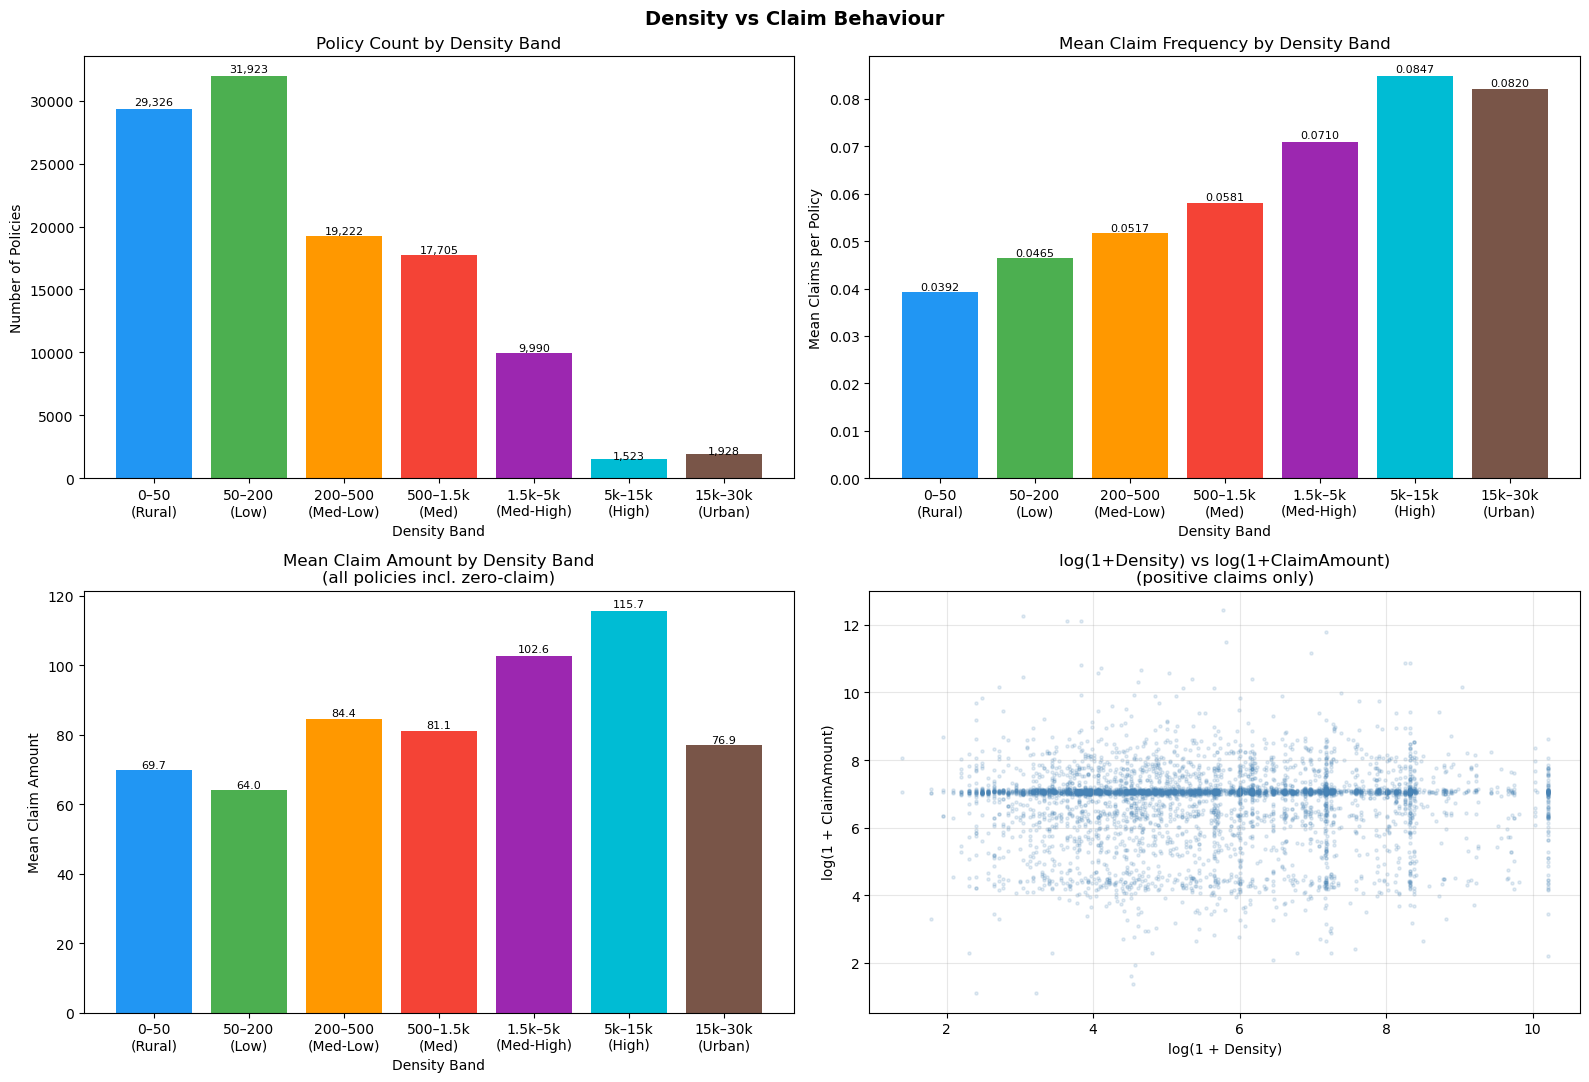

       Density_Band  Policy_Count  Claim_Frequency  Mean_ClaimAmt  Median_ClaimAmt
      0–50\n(Rural)         29326         0.039214      69.682432              0.0
      50–200\n(Low)         31923         0.046456      63.955675              0.0
 200–500\n(Med-Low)         19222         0.051712      84.438612              0.0
    500–1.5k\n(Med)         17705         0.058063      81.099859              0.0
1.5k–5k\n(Med-High)          9990         0.070971     102.603403              0.0
     5k–15k\n(High)          1523         0.084701     115.678267              0.0
   15k–30k\n(Urban)          1928         0.081950      76.866183              0.0


In [37]:
import matplotlib.pyplot as plt
import numpy as np

# ── Create Density bands (log scale makes sense given the skewed distribution)
df['Density_Band'] = pd.cut(
    df['Density'],
    bins=[0, 50, 200, 500, 1500, 5000, 15000, 30000],
    labels=['0–50\n(Rural)', '50–200\n(Low)', '200–500\n(Med-Low)',
            '500–1.5k\n(Med)', '1.5k–5k\n(Med-High)',
            '5k–15k\n(High)', '15k–30k\n(Urban)']
)

band_stats = df.groupby('Density_Band', observed=True).agg(
    Policy_Count    = (CLAIM_COUNT_COL,  'count'),
    Claim_Frequency = (CLAIM_COUNT_COL,  'mean'),
    Mean_ClaimAmt   = (CLAIM_AMOUNT_COL, 'mean'),
    Median_ClaimAmt = (CLAIM_AMOUNT_COL, 'median'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Density vs Claim Behaviour', fontsize=14, fontweight='bold')

colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4','#795548']

# ── Plot 1: Policy count per band ─────────────────────────────────────────
axes[0,0].bar(band_stats['Density_Band'], band_stats['Policy_Count'], color=colors)
axes[0,0].set_title('Policy Count by Density Band')
axes[0,0].set_xlabel('Density Band')
axes[0,0].set_ylabel('Number of Policies')
for i, v in enumerate(band_stats['Policy_Count']):
    axes[0,0].text(i, v + v*0.01, f'{v:,}', ha='center', fontsize=8)

# ── Plot 2: Claim frequency per band ──────────────────────────────────────
axes[0,1].bar(band_stats['Density_Band'], band_stats['Claim_Frequency'], color=colors)
axes[0,1].set_title('Mean Claim Frequency by Density Band')
axes[0,1].set_xlabel('Density Band')
axes[0,1].set_ylabel('Mean Claims per Policy')
for i, v in enumerate(band_stats['Claim_Frequency']):
    axes[0,1].text(i, v + v*0.01, f'{v:.4f}', ha='center', fontsize=8)

# ── Plot 3: Mean Claim Amount per band ────────────────────────────────────
axes[1,0].bar(band_stats['Density_Band'], band_stats['Mean_ClaimAmt'], color=colors)
axes[1,0].set_title('Mean Claim Amount by Density Band\n(all policies incl. zero-claim)')
axes[1,0].set_xlabel('Density Band')
axes[1,0].set_ylabel('Mean Claim Amount')
for i, v in enumerate(band_stats['Mean_ClaimAmt']):
    axes[1,0].text(i, v + v*0.01, f'{v:.1f}', ha='center', fontsize=8)

# ── Plot 4: Scatter — log(Density) vs ClaimAmount (positive claims only) ─
df_pos = df[df[CLAIM_AMOUNT_COL] > 0].copy()
axes[1,1].scatter(np.log1p(df_pos['Density']),
                  np.log1p(df_pos[CLAIM_AMOUNT_COL]),
                  alpha=0.15, s=5, color='steelblue')
axes[1,1].set_title('log(1+Density) vs log(1+ClaimAmount)\n(positive claims only)')
axes[1,1].set_xlabel('log(1 + Density)')
axes[1,1].set_ylabel('log(1 + ClaimAmount)')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/density_vs_claims.png', dpi=120)
plt.show()

print(band_stats.to_string(index=False))

=== Density = 27000 vs Rest of Portfolio ===

                                      Policy Count  Claim Frequency  Mean ClaimAmount  Zero-Claim %  P95 ClaimAmount  P99 ClaimAmount
Group                                                                                                                                
Density = 27000\n(Paris City-Centre)          1434           0.0795           74.4540       92.7476           590.55           1496.3
Rest of Portfolio                           110183           0.0503           76.1164       95.1807             0.00           1249.0


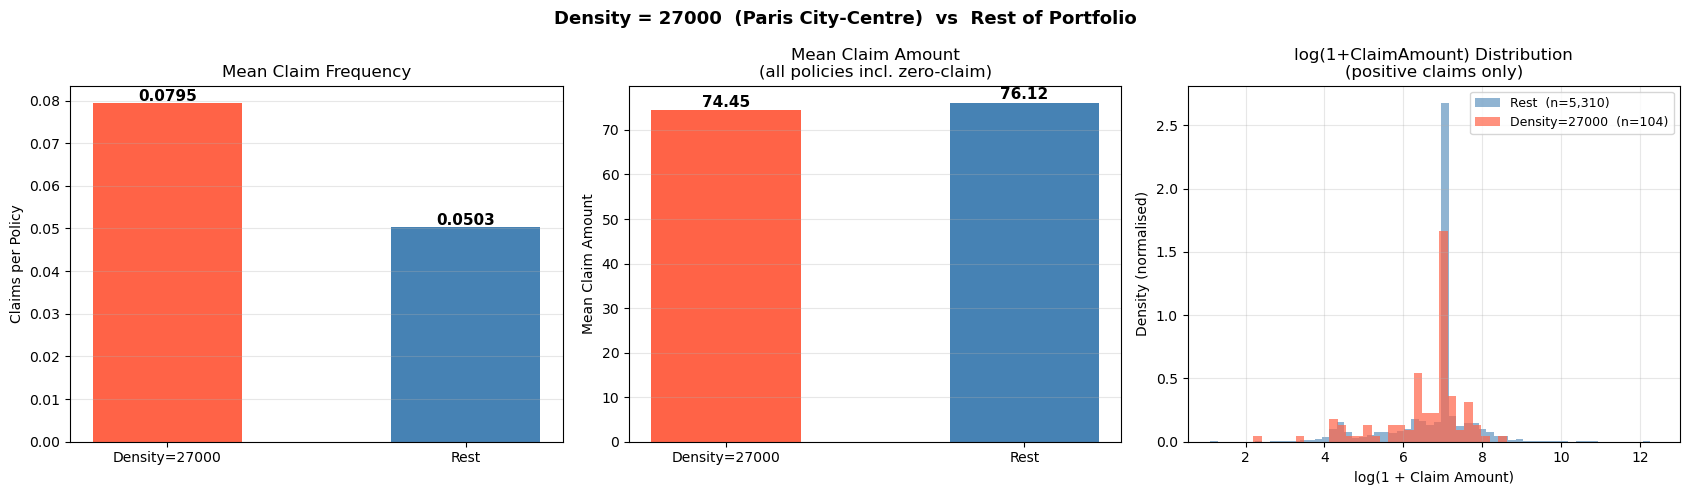

In [38]:
# ── Isolate the 27000 cluster ─────────────────────────────────────────────
df_27k  = df[df['Density'] == 27000].copy()   # 1,434 Paris city-centre policies
df_rest = df[df['Density'] != 27000].copy()   # everyone else

print('=== Density = 27000 vs Rest of Portfolio ===\n')

stats = {
    'Group'            : ['Density = 27000\n(Paris City-Centre)', 'Rest of Portfolio'],
    'Policy Count'     : [len(df_27k), len(df_rest)],
    'Claim Frequency'  : [df_27k[CLAIM_COUNT_COL].mean(),  df_rest[CLAIM_COUNT_COL].mean()],
    'Mean ClaimAmount' : [df_27k[CLAIM_AMOUNT_COL].mean(), df_rest[CLAIM_AMOUNT_COL].mean()],
    'Zero-Claim %'     : [(df_27k[CLAIM_COUNT_COL]==0).mean()*100,
                          (df_rest[CLAIM_COUNT_COL]==0).mean()*100],
    'P95 ClaimAmount'  : [df_27k[CLAIM_AMOUNT_COL].quantile(0.95),
                          df_rest[CLAIM_AMOUNT_COL].quantile(0.95)],
    'P99 ClaimAmount'  : [df_27k[CLAIM_AMOUNT_COL].quantile(0.99),
                          df_rest[CLAIM_AMOUNT_COL].quantile(0.99)],
}

stats_df = pd.DataFrame(stats).set_index('Group')
print(stats_df.round(4).to_string())

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Density = 27000  (Paris City-Centre)  vs  Rest of Portfolio',
             fontsize=13, fontweight='bold')

BLUE   = 'tomato'
GREY   = 'steelblue'

# Plot 1 — Claim Frequency comparison
freq_vals = [df_27k[CLAIM_COUNT_COL].mean(), df_rest[CLAIM_COUNT_COL].mean()]
bars = axes[0].bar(['Density=27000', 'Rest'], freq_vals, color=[BLUE, GREY], width=0.5)
axes[0].set_title('Mean Claim Frequency')
axes[0].set_ylabel('Claims per Policy')
for bar, val in zip(bars, freq_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — Mean ClaimAmount comparison
amt_vals = [df_27k[CLAIM_AMOUNT_COL].mean(), df_rest[CLAIM_AMOUNT_COL].mean()]
bars2 = axes[1].bar(['Density=27000', 'Rest'], amt_vals, color=[BLUE, GREY], width=0.5)
axes[1].set_title('Mean Claim Amount\n(all policies incl. zero-claim)')
axes[1].set_ylabel('Mean Claim Amount')
for bar, val in zip(bars2, amt_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + amt_vals[1]*0.01,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Plot 3 — ClaimAmount distribution (positive claims only)
pos_27k  = df_27k[df_27k[CLAIM_AMOUNT_COL]  > 0][CLAIM_AMOUNT_COL]
pos_rest = df_rest[df_rest[CLAIM_AMOUNT_COL] > 0][CLAIM_AMOUNT_COL]

axes[2].hist(np.log1p(pos_rest), bins=60, alpha=0.6, color=GREY,
             label=f'Rest  (n={len(pos_rest):,})', density=True)
axes[2].hist(np.log1p(pos_27k),  bins=30, alpha=0.7, color=BLUE,
             label=f'Density=27000  (n={len(pos_27k):,})', density=True)
axes[2].set_title('log(1+ClaimAmount) Distribution\n(positive claims only)')
axes[2].set_xlabel('log(1 + Claim Amount)')
axes[2].set_ylabel('Density (normalised)')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/density_27000_analysis.png', dpi=120)
plt.show()

Observations beyond P99 in at least one variable: 3,035  (2.72%)


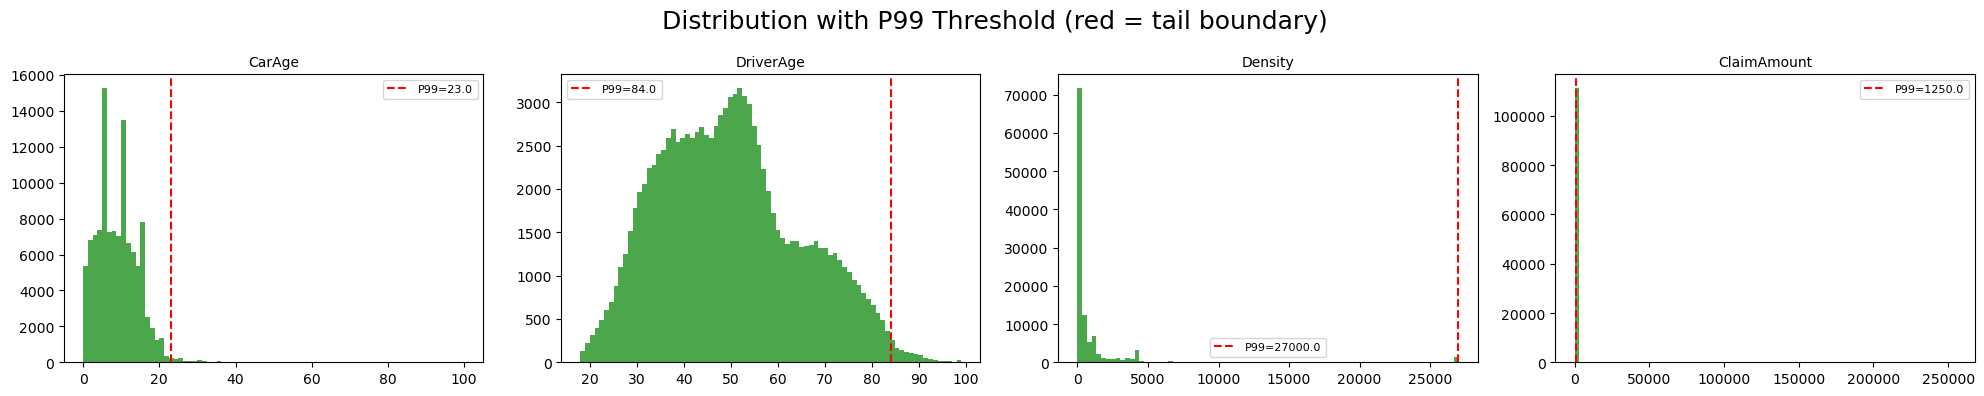

In [40]:
def tool_flag_tail_outliers(df, tail_cols, quantile=0.99):
    """
    Flags univariate tail outliers exceeding specified quantile thresholds.
    
    What this tool does:
        Calculates empirical quantile cutoff thresholds (default P99) for rating features,
        flags policies exceeding threshold in any variable, and records the reason string.
        
    Why it is used:
        Identifies extreme single-feature policies that require monitoring or clipping.
        
    Returns:
        tuple: (df_flagged, p99_threshold_series, n_flagged_count)
    """
    p99 = df[tail_cols].quantile(quantile)
    df['tail_flag'] = False
    df['tail_reason'] = ''
    
    for col in tail_cols:
        mask = df[col] > p99[col]
        df.loc[mask, 'tail_flag'] = True
        df.loc[mask, 'tail_reason'] += f'{col}>P{int(quantile*100)} '
        
    n_tail = int(df['tail_flag'].sum())
    return df, p99, n_tail

# ── Run Execution ─────────────────────────────────────────────────────────────
df, p99, n_tail = tool_flag_tail_outliers(df, TAIL_COLS, quantile=0.99)
print(f'Observations beyond P99 in at least one variable: {n_tail:,}  ({n_tail/len(df)*100:.2f}%)')

# Visualise tail for each column
n_cols = len(TAIL_COLS)
fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 4))
if n_cols == 1: axes = [axes]

for ax, col in zip(axes, TAIL_COLS):
    data = df[col].dropna()
    ax.hist(data, bins=80, color='green', edgecolor='none', alpha=0.7)
    ax.axvline(p99[col], color='red', linestyle='--', label=f'P99={p99[col]:.1f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Distribution with P99 Threshold (red = tail boundary)', fontsize=18)
plt.tight_layout()
plt.savefig('../outputs/tail_analysis.png', dpi=120)
plt.show()


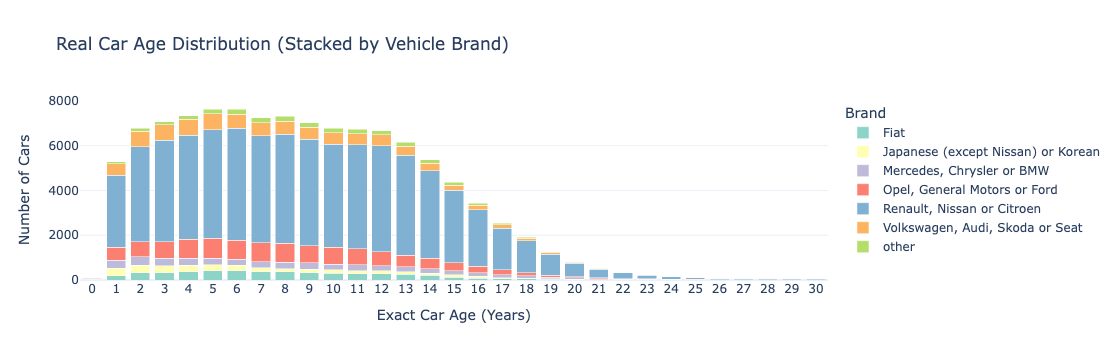

In [41]:
import plotly.express as px

# 1. Group the data to get the exact count for each Car Age and Brand
car_stats = df.groupby(['CarAge', 'Brand']).size().reset_index(name='Number of Cars')

# 2. Filter out the extreme tail just so the graph is easy to zoom and read
car_stats = car_stats[car_stats['CarAge'] <= 30]

# 3. Create an interactive stacked bar chart
fig = px.bar(
    car_stats, 
    x='CarAge', 
    y='Number of Cars', 
    color='Brand',
    title='Real Car Age Distribution (Stacked by Vehicle Brand)',
    labels={'CarAge': 'Exact Car Age (Years)'},
    hover_data={'CarAge': True, 'Brand': True, 'Number of Cars': True},
    color_discrete_sequence=px.colors.qualitative.Set3
)

# 4. Force the X-axis to show every single integer year (no binning illusions!)
fig.update_layout(
    xaxis=dict(tickmode='linear', dtick=1),
    barmode='stack',
    hovermode='closest',
    template='plotly_white'
)

# 5. Display the interactive chart
fig.show()

## 2.4 — Isolation Forest

**What this does:** Detects observations that are unusual across ALL features simultaneously — not just in one variable.

### Preprocessing pipeline:
```
Numerical → Impute median → (log-transform skewed) ─┐
                                                      ├→ Processed X → Isolation Forest
Categorical → Impute mode → One-hot encode ──────────┘
```

**Score:** Higher = more anomalous (we negate `decision_function` so it's intuitive)

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.ensemble import IsolationForest

# ── What anomaly are we detecting? ──────────────────────────────────────────
# Policy-level anomaly: unusual risk profile
# Predictor space only — do NOT include ClaimAmount or ClaimNb here
# ────────────────────────────────────────────────────────────────────────────

ISO_NUM_COLS = [c for c in NUM_COLS if c in df.columns]
ISO_CAT_COLS = [c for c in CAT_COLS if c in df.columns]

print(f'Numeric features for IF  ({len(ISO_NUM_COLS)}): {ISO_NUM_COLS}')
print(f'Categorical features for IF ({len(ISO_CAT_COLS)}): {ISO_CAT_COLS}')

Numeric features for IF  (4): ['PolicyID', 'CarAge', 'DriverAge', 'Density']
Categorical features for IF (4): ['Power', 'Brand', 'Gas', 'Region']


In [43]:
def tool_run_isolation_forest(df, num_cols, cat_cols, contamination=0.02, n_estimators=200, random_state=42):
    """
    Detects multivariate feature anomalies using an Isolation Forest pipeline.
    
    What this tool does:
        Imputes numerics (median) and categoricals (most frequent), one-hot encodes,
        and fits an ensemble of isolation trees to identify multi-dimensional outliers.
        
    Why it is used:
        Univariate filters miss anomalies where individual attributes appear normal but
        their multi-variable combination is highly abnormal.
        
    Returns:
        tuple: (df_scored, preprocessor, fitted_iso_model, shape_tuple)
    """
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    preprocessor = ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ], remainder='drop')
    
    X_processed = preprocessor.fit_transform(df)
    
    iso = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state
    )
    iso.fit(X_processed)
    
    # Score: negate so that HIGHER = more anomalous
    df['IF_Score'] = -iso.decision_function(X_processed)
    df['IF_Label'] = iso.predict(X_processed)  # -1 = anomaly, 1 = normal
    
    return df, preprocessor, iso, X_processed.shape

# ── Run Execution ─────────────────────────────────────────────────────────────
CONTAMINATION = 0.02   # 2% expected contamination
N_ESTIMATORS  = 200

df, preprocessor, iso, proc_shape = tool_run_isolation_forest(
    df, ISO_NUM_COLS, ISO_CAT_COLS, contamination=CONTAMINATION, n_estimators=N_ESTIMATORS
)

n_anomaly = int((df['IF_Label'] == -1).sum())
print(f'Processed feature matrix: {proc_shape}')
print(f'Isolation Forest flagged: {n_anomaly:,} observations ({n_anomaly/len(df)*100:.2f}%)')


Processed feature matrix: (111617, 35)
Isolation Forest flagged: 2,233 observations (2.00%)


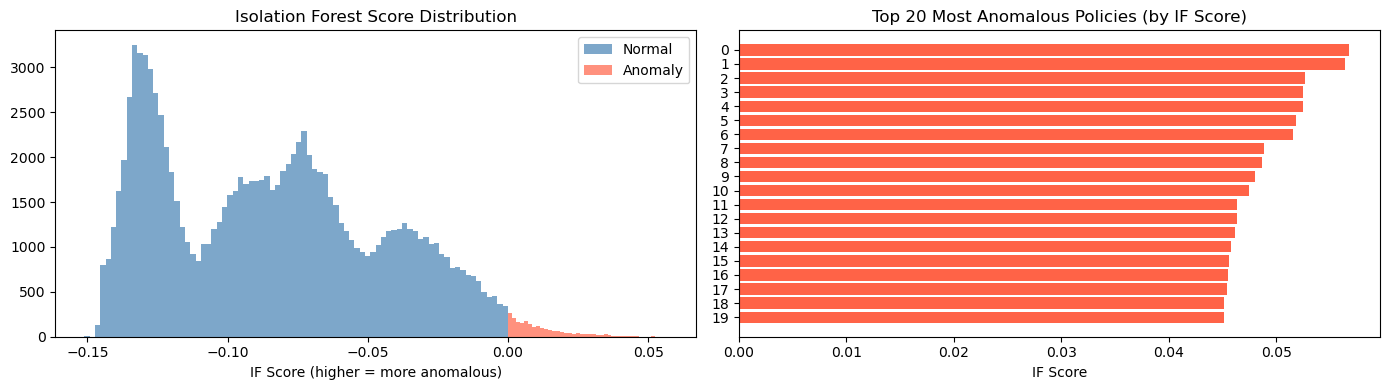

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Score distribution
axes[0].hist(df[df['IF_Label']==1]['IF_Score'],  bins=80, alpha=0.7, color='steelblue', label='Normal')
axes[0].hist(df[df['IF_Label']==-1]['IF_Score'], bins=40, alpha=0.7, color='tomato',    label='Anomaly')
axes[0].set_title('Isolation Forest Score Distribution')
axes[0].set_xlabel('IF Score (higher = more anomalous)')
axes[0].legend()

# Top 20 anomalies by score
top20 = df.nlargest(20, 'IF_Score')[ISO_NUM_COLS[:4] + ['IF_Score']].reset_index()
axes[1].barh(top20.index.astype(str), top20['IF_Score'], color='tomato')
axes[1].set_title('Top 20 Most Anomalous Policies (by IF Score)')
axes[1].set_xlabel('IF Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/isolation_forest.png', dpi=120)
plt.show()

In [45]:
# Show top 30 anomalous observations — INVESTIGATE these
investigate_cols = ISO_NUM_COLS + ISO_CAT_COLS + ['IF_Score', 'tail_flag', 'tail_reason']
investigate_cols = [c for c in investigate_cols if c in df.columns]

top30 = df[df['IF_Label'] == -1].nlargest(30, 'IF_Score')[investigate_cols]
print(f'=== Top 30 Anomalies to Investigate ===')
top30

=== Top 30 Anomalies to Investigate ===


,PolicyID,CarAge,DriverAge,Density,Power,Brand,Gas,Region,IF_Score,tail_flag,tail_reason
111217,111218,4,82,27000,i,"Mercedes, Chrysler or BMW",Diesel,Ile-de-France,0.056795,False,
107172,107173,18,79,27000,m,other,Regular,Ile-de-France,0.056379,False,
110657,110658,13,78,27000,j,Japanese (except Nissan) or Korean,Regular,Ile-de-France,0.052661,False,
67828,67829,20,72,27000,l,"Mercedes, Chrysler or BMW",Diesel,Ile-de-France,0.052496,False,
109850,109851,1,69,27000,k,other,Regular,Ile-de-France,0.052461,False,
110982,110983,2,46,27000,l,Japanese (except Nissan) or Korean,Regular,Ile-de-France,0.051797,False,
89417,89418,3,81,27000,i,"Mercedes, Chrysler or BMW",Diesel,Ile-de-France,0.051578,False,
104258,104259,1,30,27000,j,Japanese (except Nissan) or Korean,Regular,Ile-de-France,0.048847,False,
110991,110992,2,65,27000,m,"Mercedes, Chrysler or BMW",Regular,Ile-de-France,0.048696,False,
98123,98124,1,32,27000,l,Japanese (except Nissan) or Korean,Diesel,Ile-de-France,0.048015,False,


## 2.5 — Leverage Scoring

**What this does:** Identifies observations with unusual positions in the *predictor space* — even if their claim value looks normal.

We use the **hat matrix diagonal** $h_{ii} = [X(X^TX)^{-1}X^T]_{ii}$

Threshold: $h_{ii} > \dfrac{2p}{n}$ (standard diagnostic rule)

In [46]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

def tool_calculate_leverage(df, num_cols, leverage_multiplier=2.0):
    """
    Computes Hat Matrix diagonal leverage (h_ii) in the predictor space.
    
    What this tool does:
        Standardizes numeric rating features, adds an intercept, computes the Hat Matrix
        diagonals h_ii = diag(X(X^T X)^{-1} X^T), and flags points exceeding threshold = 2p/n.
        
    Why it is used:
        Identifies policyholders positioned far from the predictor centroid, which can
        single-handedly pull regression planes away from the true population parameters.
        
    Returns:
        tuple: (df_with_leverage, threshold, p_parameters, n_observations)
    """
    X_num = df[num_cols].fillna(df[num_cols].median()).values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_num)
    X_sm = sm.add_constant(X_scaled)
    
    try:
        XtX_inv = np.linalg.pinv(X_sm.T @ X_sm)
        H_diag  = np.einsum('ij,jk,ik->i', X_sm, XtX_inv, X_sm)  # efficient diagonal
    except Exception:
        H_diag = np.full(len(df), np.nan)
        print('⚠ Leverage computation skipped (dataset too large for hat matrix)')
        
    n = len(df)
    p = X_sm.shape[1]  # number of parameters (including intercept)
    threshold = leverage_multiplier * (p / n)
    
    df['Leverage'] = H_diag
    df['high_leverage'] = df['Leverage'] > threshold
    
    return df, threshold, p, n

# ── Run Execution ─────────────────────────────────────────────────────────────
df, threshold, p, n = tool_calculate_leverage(df, ISO_NUM_COLS, leverage_multiplier=2.0)
n_high_lev = int(df['high_leverage'].sum())
print(f'Parameters p      : {p}')
print(f'Average leverage  : {p/n:.6f}')
print(f'Threshold (2p/n)  : {threshold:.6f}')
print(f'High-leverage obs : {n_high_lev:,}  ({n_high_lev/n*100:.2f}%)')


Parameters p      : 5
Average leverage  : 0.000045
Threshold (2p/n)  : 0.000090
High-leverage obs : 3,947  (3.54%)


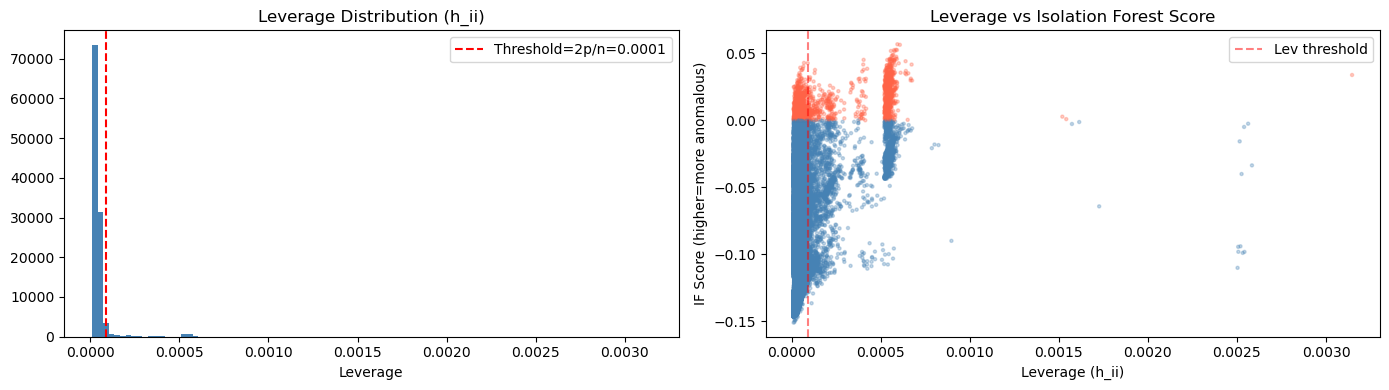

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Leverage distribution
axes[0].hist(df['Leverage'], bins=100, color='steelblue', edgecolor='none')
axes[0].axvline(threshold, color='red', linestyle='--', label=f'Threshold=2p/n={threshold:.4f}')
axes[0].set_title('Leverage Distribution (h_ii)')
axes[0].set_xlabel('Leverage')
axes[0].legend()

# Leverage vs IF Score scatter
axes[1].scatter(df['Leverage'], df['IF_Score'],
                c=df['IF_Label'].map({1:'steelblue',-1:'tomato'}),
                alpha=0.3, s=5)
axes[1].axvline(threshold, color='red', linestyle='--', alpha=0.5, label='Lev threshold')
axes[1].set_title('Leverage vs Isolation Forest Score')
axes[1].set_xlabel('Leverage (h_ii)')
axes[1].set_ylabel('IF Score (higher=more anomalous)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/leverage.png', dpi=120)
plt.show()

## 2.6 — Residual Analysis (Deviance Residuals)

We fit a quick Poisson GLM to get residuals.

**Residual** = actual − predicted.
Large residual → the model cannot explain this observation's claim count.

Poisson GLM fitted | AIC: 44867.4 | Deviance: 33830.9


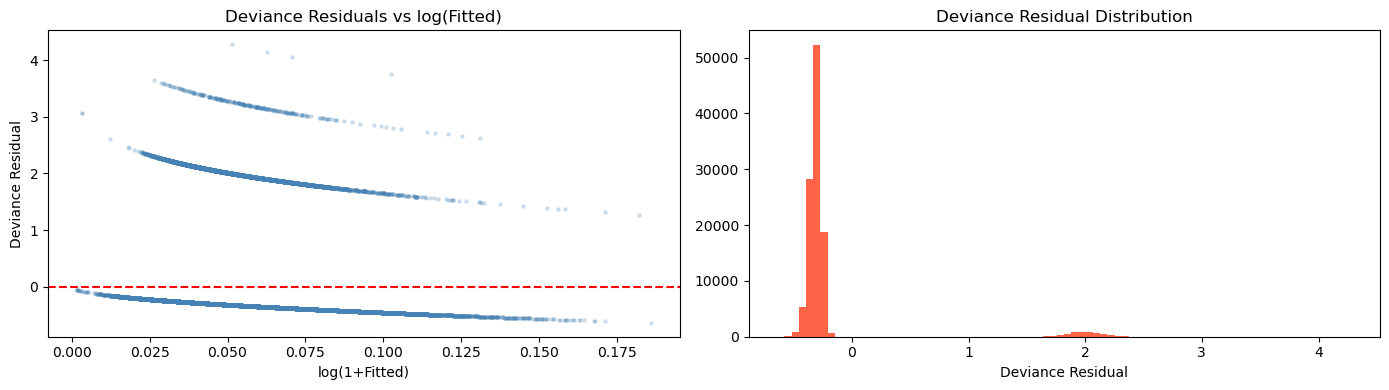

In [48]:
def tool_calculate_deviance_residuals(df, num_cols, cat_cols, claim_count_col, exposure_col=None):
    """
    Fits diagnostic Poisson GLM and computes signed deviance residuals.
    
    What this tool does:
        Estimates baseline Poisson rate with log-exposure offset and calculates
        signed Poisson deviance residuals r_i^D = sign(y - mu) * sqrt(2 * (y * ln(y/mu) - (y - mu))).
        
    Why it is used:
        Quantifies model prediction error on count data to detect policyholders whose claim
        behavior cannot be explained by standard rating factors.
        
    Returns:
        tuple: (df_with_residuals, fitted_glm_model)
    """
    if not claim_count_col or claim_count_col not in df.columns:
        df['GLM_Pred']     = np.nan
        df['Residual_Dev'] = np.nan
        df['Residual_Raw'] = np.nan
        return df, None
        
    df_enc = df[num_cols].fillna(df[num_cols].median())
    df_enc_cat = pd.get_dummies(df[cat_cols].fillna('Unknown'), drop_first=True, dtype=float)
    X_glm = pd.concat([df_enc, df_enc_cat], axis=1)
    X_glm_sm = sm.add_constant(X_glm.astype(float))

    y_glm = df[claim_count_col].values.astype(float)
    if exposure_col and exposure_col in df.columns:
        offset_glm = np.log(np.clip(df[exposure_col].values.astype(float), 1e-12, None))
    else:
        offset_glm = np.zeros(len(df))

    glm_res = sm.GLM(
        y_glm, X_glm_sm,
        family=sm.families.Poisson(link=sm.families.links.Log()),
        offset=offset_glm
    ).fit(maxiter=50)

    df['GLM_Pred']     = glm_res.fittedvalues
    df['Residual_Dev'] = glm_res.resid_deviance
    df['Residual_Raw'] = y_glm - glm_res.fittedvalues
    
    return df, glm_res

# ── Run Execution ─────────────────────────────────────────────────────────────
if CLAIM_COUNT_COL:
    df, glm_res = tool_calculate_deviance_residuals(
        df, ISO_NUM_COLS, ISO_CAT_COLS, CLAIM_COUNT_COL, EXPOSURE_COL
    )
    print(f'Poisson GLM fitted | AIC: {glm_res.aic:.1f} | Deviance: {glm_res.deviance:.1f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].scatter(np.log1p(df['GLM_Pred']), df['Residual_Dev'], alpha=0.2, s=5, color='steelblue')
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title('Deviance Residuals vs log(Fitted)')
    axes[0].set_xlabel('log(1+Fitted)'); axes[0].set_ylabel('Deviance Residual')

    axes[1].hist(df['Residual_Dev'], bins=80, color='tomato', edgecolor='none')
    axes[1].set_title('Deviance Residual Distribution')
    axes[1].set_xlabel('Deviance Residual')

    plt.tight_layout()
    plt.savefig('../outputs/residuals.png', dpi=120)
    plt.show()
else:
    print('⚠ No claim count column — skipping residual step')


## 2.7 — Influence Check

**Influence = High Leverage + Large Residual**

```
                  │  Low Residual   │  High Residual
──────────────────┼─────────────────┼─────────────────
 Low Leverage     │  ✅ Normal      │  🟠 Vertical outlier
 High Leverage    │  🟠 Unusual X   │  🔴 INFLUENTIAL
```

High leverage   : 3,947
High residual   : 209
INFLUENTIAL     : 11  (high leverage AND high residual)


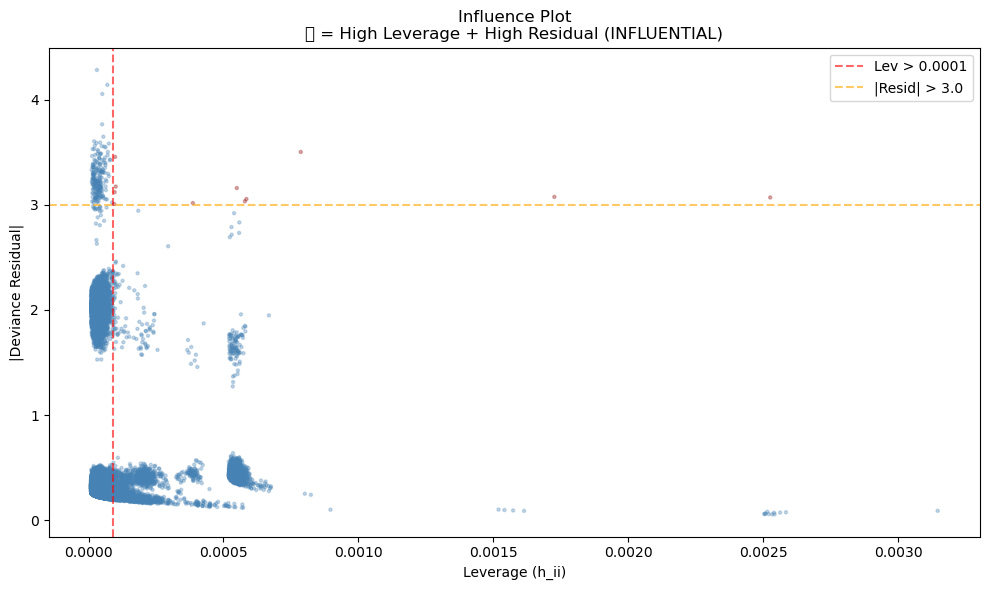

In [49]:
def tool_identify_influential_points(df, resid_threshold=3.0):
    """
    Identifies influential points combining high leverage with large deviance residuals.
    
    What this tool does:
        Flags observations where |Residual_Dev| > resid_threshold and high_leverage is True.
        
    Why it is used:
        Points with extreme leverage AND large prediction error have the highest Cook's distance
        proxy, threatening regression stability.
        
    Returns:
        tuple: (df_updated, n_influential)
    """
    df['high_residual'] = df['Residual_Dev'].abs() > resid_threshold
    df['influential']   = df['high_leverage'] & df['high_residual']
    n_inf = int(df['influential'].sum())
    return df, n_inf

# ── Run Execution ─────────────────────────────────────────────────────────────
RESID_THRESHOLD = 3.0
df, n_inf = tool_identify_influential_points(df, resid_threshold=RESID_THRESHOLD)

print(f'High leverage   : {df["high_leverage"].sum():,}')
print(f'High residual   : {df["high_residual"].sum():,}')
print(f'INFLUENTIAL     : {n_inf:,}  (high leverage AND high residual)')

# Leverage vs Residual diagnostic plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = df['influential'].map({True:'darkred', False:'steelblue'})
ax.scatter(df['Leverage'], df['Residual_Dev'].abs(), c=colors, alpha=0.3, s=5)
ax.axvline(threshold,       color='red',    linestyle='--', alpha=0.6, label=f'Lev > {threshold:.4f}')
ax.axhline(RESID_THRESHOLD, color='orange', linestyle='--', alpha=0.6, label=f'|Resid| > {RESID_THRESHOLD}')
ax.set_xlabel('Leverage (h_ii)')
ax.set_ylabel('|Deviance Residual|')
ax.set_title('Influence Plot\n🔴 = High Leverage + High Residual (INFLUENTIAL)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/influence_plot.png', dpi=120)
plt.show()


## 2.8 — Business Review Table

For each flagged observation, we classify it as:

| Classification | Condition | Action |
|---|---|---|
| 🔴 **Likely Error** | IF anomaly + tail + impossible value | **FIX / REMOVE** |
| 🟠 **Suspicious** | IF anomaly + influential | **Investigate** |
| 🟡 **Rare but valid** | Tail only OR leverage only | **KEEP + flag** |
| 🟢 **Normal** | None of the above | **KEEP** |

In [50]:
def tool_classify_business_review(df):
    """
    Categorizes flagged observations into the 4-tier Actuarial Business Review Matrix.
    
    What this tool does:
        Merges statistical flags (Isolation Forest, Tail P99, Influence, Leverage) into:
        - 🔴 Likely Error (IF + Tail + Influential)
        - 🟠 Suspicious (IF + Influential, or IF + Tail)
        - 🟡 Rare / Unusual (Single dimension anomaly)
        - 🟢 Normal (Clean baseline)
        
    Why it is used:
        Fulfills ASOP 23 audit governance, providing an explainable decision basis
        to keep legitimate high risks while isolating true data corruptions.
        
    Returns:
        pd.DataFrame: df with added 'Review_Class' column.
    """
    def classify_row(row):
        is_if   = row.get('IF_Label') == -1
        is_tail = bool(row.get('tail_flag', False))
        is_inf  = bool(row.get('influential', False))
        is_lev  = bool(row.get('high_leverage', False))

        if is_if and is_tail and is_inf:
            return '🔴 Likely Error'
        elif is_if and is_inf:
            return '🟠 Suspicious'
        elif is_if and is_tail:
            return '🟠 Suspicious'
        elif is_if:
            return '🟡 Rare (IF only)'
        elif is_tail:
            return '🟡 Rare (Tail only)'
        elif is_lev:
            return '🟡 Unusual predictor'
        else:
            return '🟢 Normal'

    df['Review_Class'] = df.apply(classify_row, axis=1)
    return df

# ── Run Execution ─────────────────────────────────────────────────────────────
df = tool_classify_business_review(df)

print('=== Business Review Summary ===')
print(df['Review_Class'].value_counts().to_string())


=== Business Review Summary ===
Review_Class
🟢 Normal               104695
🟡 Rare (Tail only)       2879
🟡 Rare (IF only)         2077
🟡 Unusual predictor      1810
🟠 Suspicious              154
🔴 Likely Error              2


In [51]:
# Show the flagged observations (non-normal) for your review
flagged = df[df['Review_Class'] != '🟢 Normal'].copy()
show_cols = ISO_NUM_COLS[:5] + ['IF_Score', 'Leverage', 'Residual_Dev', 'tail_reason', 'Review_Class']
show_cols = [c for c in show_cols if c in flagged.columns]

print(f'Total flagged: {len(flagged):,}  |  Showing top 50 by IF score')
flagged.nlargest(50, 'IF_Score')[show_cols]

Total flagged: 6,922  |  Showing top 50 by IF score


,PolicyID,CarAge,DriverAge,Density,IF_Score,Leverage,Residual_Dev,tail_reason,Review_Class
111217,111218,4,82,27000,0.056795,0.000593,-0.495800,,🟡 Rare (IF only)
107172,107173,18,79,27000,0.056379,0.000607,-0.385624,,🟡 Rare (IF only)
110657,110658,13,78,27000,0.052661,0.000585,-0.421507,,🟡 Rare (IF only)
67828,67829,20,72,27000,0.052496,0.000590,-0.384736,,🟡 Rare (IF only)
109850,109851,1,69,27000,0.052461,0.000574,-0.521149,,🟡 Rare (IF only)
110982,110983,2,46,27000,0.051797,0.000556,-0.497518,,🟡 Rare (IF only)
89417,89418,3,81,27000,0.051578,0.000577,-0.517799,,🟡 Rare (IF only)
104258,104259,1,30,27000,0.048847,0.000570,-0.551329,,🟡 Rare (IF only)
110991,110992,2,65,27000,0.048696,0.000565,-0.519287,,🟡 Rare (IF only)
98123,98124,1,32,27000,0.048015,0.000561,-0.570144,,🟡 Rare (IF only)


## 2.9 — Decision: KEEP or REMOVE?

👇 **Review the table above and set your decision here.**

- `'🔴 Likely Error'` → remove by default
- `'🟠 Suspicious'` → you decide
- Everything else → keep

In [52]:
# ── SET YOUR DECISION ──────────────────────────────────────────────────────
# List the Review_Class labels you want to REMOVE
REMOVE_CLASSES = [
    '🔴 Likely Error',
    # '🟠 Suspicious',   # ← uncomment if you also want to remove suspicious
]
# ───────────────────────────────────────────────────────────────────────────

mask_remove = df['Review_Class'].isin(REMOVE_CLASSES)
mask_keep   = ~mask_remove

df_clean = df[mask_keep].copy()

print(f'Original rows : {len(df):,}')
print(f'Removed       : {mask_remove.sum():,}')
print(f'Clean dataset : {len(df_clean):,}')

Original rows : 111,617
Removed       : 2
Clean dataset : 111,615


## 2.10 — Save Clean Dataset

In [53]:
import pickle

# Drop the diagnostic columns before saving to keep things clean
diag_cols = ['IF_Score','IF_Label','tail_flag','tail_reason',
             'Leverage','high_leverage','GLM_Pred','Residual_Dev',
             'Residual_Raw','high_residual','influential','Review_Class']
df_clean_out = df_clean.drop(columns=[c for c in diag_cols if c in df_clean.columns])

df_clean_out.to_parquet('../outputs/df_clean.parquet', index=False)

# Save anomaly report for reference
anomaly_report = df[show_cols + ['Review_Class']].copy()
anomaly_report.to_csv('../outputs/anomaly_report.csv', index=True)

# Save preprocessor for later reuse
with open('../outputs/iso_preprocessor.pkl','wb') as f:
    pickle.dump({'preprocessor': preprocessor, 'iso': iso}, f)

print(f'✅ outputs/df_clean.parquet     ({len(df_clean_out):,} rows)')
print(f'✅ outputs/anomaly_report.csv')
print(f'✅ outputs/iso_preprocessor.pkl')

✅ outputs/df_clean.parquet     (111,615 rows)
✅ outputs/anomaly_report.csv
✅ outputs/iso_preprocessor.pkl


In [22]:
# what is the p & n again 
# In statistical diagnostics and linear regression context:

# p is the number of parameters (or features/predictors) in the model, including the intercept constant term. In your notebook output, p=5 (meaning 4 scaled features + 1 constant term).

# n is the total number of observations (or rows/sample size) in your dataset.

# How they are used here:

# Average Leverage (p/n): The average distance of all observations from the mean center of the predictor space. In your output, this is 5/n=0.000045, which implies your dataset has n=111,111 total rows (5/0.000045).

# Threshold (2p/n): The standard rule-of-thumb cutoff value (2×0.000045=0.000090). Any observation with a leverage value h 
# ii
# ​
#   higher than this threshold is flagged as a high-leverage anomaly because its predictor values lie far away from the bulk of the data.

# what about this code
# In Cell [13], the code is visualising your leverage calculations and comparing them against another anomaly detection model (Isolation Forest).

# Here is what each subplot does:

# Left Plot (Leverage Distribution):

# Plots a histogram showing how leverage scores (h 
# ii
# ​
#  ) are distributed across all policyholders.

# Adds a vertical dashed red line at the cutoff threshold (Threshold=2p/n=0.0001).

# Goal: Visualises how heavily skewed your feature space is and how many observations stick out past the cutoff line.

# Right Plot (Leverage vs. Isolation Forest Score):

# Plots Leverage (h 
# ii
# ​
#  ) on the X-axis against Isolation Forest Score (IF_Score) on the Y-axis.

# Colors points based on their Isolation Forest label (blue for normal, red/tomato for anomalies).

# Goal: Cross-validates two distinct anomaly detection techniques. It shows whether points flagged as high-leverage (extreme features) are also flagged by Isolation Forest (multivariate isolation).

# Finally, it saves the figure to ../outputs/leverage.png and displays it.

# Would you like to look into how to handle the observations flagged in the top-right quadrant of that scatter plot?

# Clearly explain the right plot
# The scatter plot on the right visually compares two different anomaly detection techniques to see if they agree on which insurance policies are unusual: Leverage Score (h 
# ii
# ​
#  ) on the X-axis and Isolation Forest Score (IF_Score) on the Y-axis.

# X-Axis (Leverage Score h 
# ii
# ​
#  ): Measures how extreme an observation's feature values are compared to the rest of the dataset. Higher values mean the policyholder has unusual predictor attributes.

# Y-Axis (Isolation Forest Score): Measures how easy it is to isolate an observation using decision trees. Higher values indicate points that are overall multivariate anomalies.

# Vertical Dashed Red Line: Marks the theoretical cutoff threshold (Threshold=2p/n=0.0001). Points to the right of this line are tagged as high-leverage anomalies.

# Color Encoding: Points flagged as normal by the Isolation Forest are colored blue, while those flagged as anomalies by the Isolation Forest are colored red/tomato.

# Key Takeaway from the Visualization:

# The plot reveals where both algorithms align and where they disagree:

# Top-Right Region (Strong Consensus): Points here have high leverage and high Isolation Forest scores (colored red). These are high-confidence anomalies with extreme feature combinations that strongly pull on linear models.

# Top-Left Region (Isolation Forest Anomalies Only): High Isolation Forest scores but low leverage. These observations are unusual in non-linear or complex interactions across multiple variables, even though their individual continuous features look average.

# Bottom-Right Region (High-Leverage Outliers): Points past the red dashed line that Isolation Forest considers normal (blue). These are extreme continuous feature values that do not necessarily form isolated clusters in tree space.

# This code also 
# In Cell [14], the code fits a Poisson Generalized Linear Model (GLM) to calculate deviance residuals for actual vs. predicted claim counts.

# Here is what the code is doing step-by-step:

# Prepares Model Inputs:

# Imputes missing numerical features with their median.

# One-hot encodes categorical features using pd.get_dummies.

# Adds an intercept constant and sets up the exposure offset (log(exposure)), which accounts for differences in policy duration.

# Fits the Poisson GLM:

# Uses statsmodels to fit a Poisson GLM with a log-link function on the target CLAIM_COUNT_COL.

# Calculates Predictions & Residuals:

# GLM_Pred: Model-predicted expected claim count for each policy.

# Residual_Dev (Deviance Residuals): Measures how far off the prediction is from the actual claim count, normalized for Poisson-distributed data. Large residuals mean the model failed to accurately predict that observation.

# Residual_Raw: Standard y− 
# y
# ^
# ​
#   difference.

# Plots Residual Diagnostics:

# Left Plot (Scatter): Plots Deviance Residuals against log(1+Fitted). It helps verify if residuals are randomly distributed around zero (red dashed line) or if systemic bias exists.

# Right Plot (Histogram): Shows the overall distribution of deviance residuals to spot severe over-prediction or under-prediction tails.

# How it ties into Anomaly Detection:

# This sets up the 2x2 matrix shown in Section 2.7:

# High Leverage + High Residual = Influential Point. These are high-risk observations that disproportionately pull and distort your GLM pricing parameters.

# Would you like to write a quick function to calculate Cook's Distance or identify the exact policy IDs sitting in that red "Influential" quadrant?

# And what about the grpahs 
# The two diagnostic graphs in Cell [14] evaluate how well your Poisson GLM fits the claim count data and highlight where the model fails to explain policyholder behavior.

# Left Graph: Deviance Residuals vs. log(1+Fitted)

# X-Axis (log(1+Fitted)): The predicted log claim count from the model.

# Y-Axis (Deviance Residual): How far off the model's prediction is from the actual claim count for each policyholder.

# Red Dashed Line (y=0): Perfect agreement between actual and predicted claims. Points on this line mean zero residual error.

# Interpretation of the Patterns:

# Bottom Band (<0): Represents policies with 0 actual claims. Because the model predicts a small positive number ( 
# y
# ^
# ​
#  >0), 0− 
# y
# ^
# ​
#   results in slight negative deviance residuals.

# Upper Curved Lines (>0): Represent policies with 1 or more actual claims. Because claim counts are discrete integers (1, 2, 3...), they form distinct distinct curved bands above zero. Higher residuals mean the model severely under-predicted the risk for a policy that actually filed claims.

# Right Graph: Deviance Residual Distribution

# X-Axis (Deviance Residual): The range of residual errors across the entire dataset.

# Y-Axis (Count): Frequency of policyholders falling into each residual bin.

# Interpretation:

# The vast majority of observations cluster near zero (or slightly negative for 0-claim policies), indicating the model fits standard policyholders well.

# Right-Tail Spikes (>3.0): Observations extending far to the right represent severe under-predictions—policies that generated an unexpected high frequency of claims. These are your candidate high-residual outliers.

# What about the influence check
# The Influence Check in Cell [15] combines your two previous diagnostic measures—Leverage (h 
# ii
# ​
#  ) and Deviance Residuals—to identify the small fraction of observations that can heavily distort your GLM pricing model parameters.

# The Core Concept

# Leverage (X-space): Measures how extreme/unusual a policyholder’s feature values are.

# Residual (Y-space): Measures how wrong the model’s claim prediction is for that policyholder.

# Influence (X+Y): An observation is only Influential when it has both extreme feature values AND a large prediction error.

# Breakdown of the 4 Quadrants

# Bottom-Left (Normal): Low leverage, low residual. Standard policyholders that the model fits well.

# Bottom-Right (Unusual X): High leverage, low residual (3,936 points). These policyholders have unusual features, but the model already predicts their claims accurately. They don't distort the model.

# Top-Left (Vertical Outliers): Low leverage, high residual (198 points). Unexpected claim activity on average policyholders. They increase overall error, but don't single-handedly swing the regression line.

# Top-Right (INFLUENTIAL): High leverage, high residual (∣h 
# ii
# ​
#  ∣>0.0001 AND ∣Residual∣>3.0). Marked in red on your plot.

# Notebook Summary & Action

# Out of your dataset, the code flagged 11 INFLUENTIAL policies (0.01% of total).

# These 11 policyholders are dangerous for GLM pricing because their extreme predictor values coupled with high claim errors pull the model coefficients toward themselves, distorting prices for everyone else.

# As outlined in Section 2.8, these 11 policies should be isolated, investigated for data entry errors, or given custom underwriting rules rather than being fed raw into the main pricing model.

# About the grpah
# The Influence Plot in Cell [15] maps Leverage on the X-axis against the absolute Deviance Residual on the Y-axis to single out points that threaten your model's stability.

# Graph Components

# X-Axis (Leverage h 
# ii
# ​
#  ): Distance of feature values from the mean center. High values mean unusual policyholder attributes.

# Y-Axis (∣Deviance Residual∣): Absolute magnitude of model prediction error. High values mean the model severely under- or over-predicted claims.

# Vertical Dashed Red Line (Lev>0.0001): Cutoff for high leverage.

# Horizontal Dashed Orange Line (∣Resid∣>3.0): Cutoff for large prediction errors.

# Color Bolding: Observations meeting both conditions are highlighted in red dots, while standard or non-influential points remain blue.

# Visual Regions & Data Layout

# Dense Clusters at Bottom (y≈0.3 to 0.5): The heavy blue horizontal bands at the bottom represent the vast majority of standard policyholders with 0 claims where the model prediction error is low.

# Upper Clusters (y≈1.5 to 2.5): Distinct groups of policies that had claims, resulting in moderate deviance residuals.

# Points above the Orange Line (y>3.0): The 209 observations where the model suffered large prediction errors.

# Red Points in the Upper-Right Quadrant: The 11 INFLUENTIAL policies sitting above y=3.0 and to the right of x=0.0001.

# Why it matters: Points strictly in the high-residual region (top-left) add noise, but points in the top-right quadrant actively pull the GLM regression parameters toward themselves, skewing pricing rates for normal policyholders.

# and the business rewiev table
# The Business Review Table (Section 2.8) translates the complex statistical flags into actionable decisions for your business and underwriting teams.

# Instead of treating every anomaly the same, it creates a tiered hierarchy based on how many risk signals an observation triggers.

# Tiered Classification Hierarchy

# 🔴 Likely Error (2 policies): Meets all three extreme flags—Isolation Forest Anomaly, Statistical Tail Outlier, and Model Influential. These represent severe data corruptions or impossible values that must be fixed or removed before pricing.

# 🟠 Suspicious (154 policies): Combines Isolation Forest detection with either high model influence or extreme tail behavior. These require manual review by underwriters to check for potential fraud or misclassified risk.

# 🟡 Rare / Unusual (6,766 total policies): Triggered only one specific anomaly type (e.g., extreme CarAge or high leverage alone). These are legitimate, extreme policyholders. You keep them in the dataset, but flag them so their high risk is appropriately priced or capped.

# 🟢 Normal (104,695 policies): The vast majority (~94%) of your dataset, clean and ready for standard GLM pricing models.

# This step ensures you only discard true data errors while keeping valid high-risk customers in your model without letting them distort the pricing math.

# total flaged ones
# According to the output in Cell [31], there are 7,922 total flagged policyholders (non-normal observations).

# Here is the breakdown of those 7,922 flagged policies across the review categories:

# 🟢 Normal: 104,695 (Clean baseline)

# 🟡 Rare (Tail only): 2,879

# 🟡 Rare (IF only): 2,077

# 🟡 Unusual predictor: 1,810

# 🟠 Suspicious: 154

# 🔴 Likely Error: 2

# decission keep or remove how does that work
# In Section 2.9, the decision logic filters out unwanted rows before passing the dataset to your main pricing model.

# It works by using a matching rule based on the Review_Class column created earlier in your notebook:

# Specify What to Remove: The variable REMOVE_CLASSES is set as a list containing the categories you want to discard. By default, it is configured as:

# Python
# REMOVE_CLASSES = ['🔴 Likely Error']
# Filter the Data: mask_remove checks every row to see if its Review_Class is in REMOVE_CLASSES. mask_keep flips that boolean (using ~), retaining all rows that are not marked for removal.

# Resulting Dataset: As shown in the Cell [32] execution output:

# Original rows: 111,617

# Removed: 2 (the 2 policies classified as 🔴 Likely Error)

# Clean dataset: 111,615 rows

# Customizing Your Decision

# If you also want to remove the 154 🟠 Suspicious policies (those with multiple risk flags like high leverage + isolation forest anomaly), you simply uncomment that line in the cell:

# Python
# REMOVE_CLASSES = [
#     '🔴 Likely Error',
#     '🟠 Suspicious',   # ← uncommenting this drops suspicious rows as well
# ]
# Running the cell with 🟠 Suspicious uncommented would drop 156 total rows (2 + 154), leaving you with 111,461 clean rows.

# What Happens Next (Section 2.10)

# Once df_clean is filtered, Section 2.10 strips out all temporary diagnostic columns (IF_Score, Leverage, Residual_Dev, etc.) and exports df_clean.parquet. This ensures your downstream GLM pricing models run on clean data without being distorted by severe data errors.